# 순환 신경망(Recurrent Neural Network, RNN)
## 순차 데이터
- 샘플이 서로 연관되어 있는 경우(순서가 있는 경우)
- 시계열 데이터, 자연어(문장) 데이터, 음성 데이터 등
- <img src="img/zzb.png" width="400">
- FFNN과 달리 출력이 이전 출력에 영향을 받음

## 셀
- 순환 신경망의 뉴런
- 입력 X와 이전 타임 스템의 은닉 상태 $H_p$에 곱해지는 두개의 가중치 $W_x$와 $W_h$, 절편 $b$가 존재
- <img src="img/zzc.png" width="400">
- $H = \tanh(W_x X + W_h H_p + b)$

## 정방향 계산
- <img src="img/zzd.png" width="600">
|순환층의 정방향 계산|출력층의 정방향 계산|
|---|---|
|$Z_1 = W_{1 x} X + W_{1 h} H_p + b_1$|Z_2 = HW_2 + b_2|
|$H = \tanh(Z_1)$|$A_2 = \text{sigmoid}(Z_2)$|

## 역방향 계산
- <img src="img/zze.png" width="600">


c:\Users\0627j\anaconda3\envs\NLP\lib\site-packages\tensorflow_core\python\keras\datasets\imdb.py:129: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  x_train, y_train = np.array(xs[:idx]), np.array(labels[:idx])
c:\Users\0627j\anaconda3\envs\NLP\lib\site-packages\tensorflow_core\python\keras\datasets\imdb.py:130: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  x_test, y_test = np.array(xs[idx:]), np.array(labels[idx:])


에포크: 0 .................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................
에포크: 1 ........................................................................................................................................................................................................................................................................................................................................................................

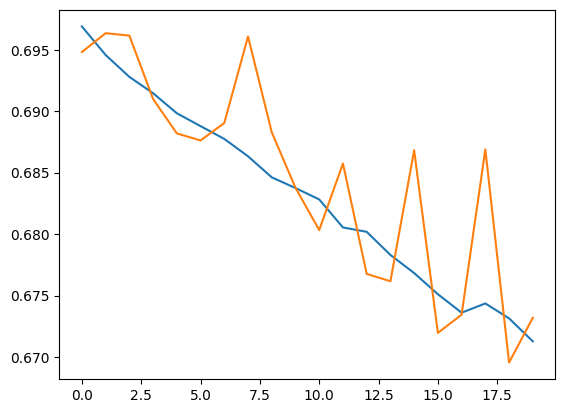

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.utils import to_categorical

# 순환 신경망
class RecurrentNetwork:
    def __init__(self, n_cells=10,  batch_size=32, learning_rate=0.1):
        self.n_cells = n_cells # 셀 수
        self.batch_size = batch_size # 커널 크기
        
        self.w1h = None # 은닉상태에 대한 가중치
        self.w1x = None # 입력에 대한 가중치
        self.b1 = None # 순환층의 절편

        self.w2 = None # 출력층의 가중치
        self.b2 = None # 출력층의 절편

        self.h = None # 순환층의 활성화 출력

        self.losses = [] # 훈련 손실
        self.val_losses = [] # 검증 손실
        self.lr = learning_rate # 학습률

    def forpass(self, x):
        self.h = [np.zeros((x.shape[0], self.n_cells))] # 은닉 상태를 초기화

        seq = np.swapaxes(x, 0, 1) # 배치 차원(0번 축: 행)과 타임 스텝 차원(1번 축: 열)을 바꿈

        for x in seq:
            z1 = np.dot(x, self.w1x) + np.dot(self.h[-1], self.w1h) + self.b1 # 바로 이전 은닉 상태 self.h[-1]와 현재 입력 x를 각각의 가중치에 곱하여 더한다.
            h = np.tanh(z1)
            self.h.append(h)
            z2 = np.dot(h, self.w2) + self.b2
        return z2


    def init_weights(self, n_features, n_classes):

        orth_init = tf.initializers.Orthogonal() # 가중치 초기화에 직교 행렬 초기화 기법 사용. 어떤 행렬에 직교 행렬을 아무리 곱해도 행렬의 크기가 변하지 않고 유지됨.
        glorot_init = tf.initializers.GlorotUniform() # 초기화 알고리즘 중 하나

        self.w1h = orth_init((self.n_cells, self.n_cells)).numpy() # (샐 개수, 샐 개수)
        self.w1x = glorot_init((n_features, self.n_cells)).numpy() # (특성 개수, 셀 개수)
        self.b1 = np.zeros(self.n_cells) # 은닉층 크기
        self.w2 = glorot_init((self.n_cells, n_classes)).numpy() # (셀 개수, 클래스 개수)
        self.b2 = np.zeros(n_classes)

    def backprop(self, x, err):
        m = len(x)

        w2_grad = np.dot(self.h[-1].T, err) / m
        b2_grad = np.sum(err) / m

        seq = np.swapaxes(x, 0, 1)

        w1h_grad = w1x_grad = b1_grad = 0
        err_to_cell = np.dot(err, self.w2.T) * (1 - self.h[-1] ** 2)

        # 모든 타임 스템을 거슬러가면서 그래디언트 전파
        for x, h in zip(seq[::-1][:10], self.h[:-1][::-1][:10]):
            w1h_grad += np.dot(h.T, err_to_cell)
            w1x_grad += np.dot(x.T, err_to_cell)
            b1_grad += np.sum(err_to_cell, axis=0)

            err_to_cell = np.dot(err_to_cell, self.w1h) * (1 - h**2) # 아지너 타임 스템의 셀 직전까지 그레디언트 게산
        
        w1h_grad /= m
        w1x_grad /= m
        b1_grad /= m

        return w1h_grad, w1x_grad, b1_grad, w2_grad, b2_grad

    def sigmoid(self, z):
        z = np.clip(z, -100, None)
        a = 1 / (1 + np.exp(-z))
        return a

    def fit(self, x, y, epochs=100, x_val=None, y_val=None):
        y = y.reshape(-1, 1)
        y_val = y_val.reshape(-1, 1)

        np.random.seed(42)
        self.init_weights(x.shape[2], y.shape[1]) # 은닉층과 출력층 가중치 초기화
        for i in range(epochs):
            print('에포크:', i, end = ' ')
            batch_losses = []
            for x_batch, y_batch in self.gen_batch(x, y):
                print('.', end='')
                a = self.training(x_batch, y_batch)
                a = np.clip(a, 1e-10, 1 - 1e-10)
                loss = np.mean(-(y_batch*np.log(a) + (1-y_batch)*np.log(1-a)))
                batch_losses.append(loss)
            print()
            self.losses.append(np.mean(batch_losses))
            self.update_val_loss(x_val, y_val)
    
    def gen_batch(self, x, y):

        length = len(x)

        bins = length // self.batch_size

        if length % self.batch_size:
            bins += 1

        indexes = np.random.permutation(np.arange(len(x)))
        x = x[indexes]
        y = y[indexes]
        for i in range(bins):
            start = self.batch_size * i
            end = self.batch_size * (i+1)
            yield x[start:end], y[start:end]

    def training(self, x, y):
        m = len(x)
        z = self.forpass(x)
        a = self.sigmoid(z)
        err = -(y-a)

        w1h_grad, w1x_grad, b1_grad, w2_grad, b2_grad = self.backprop(x, err)

        self.w1h -= self.lr * w1h_grad
        self.w1x -= self.lr * w1x_grad
        self.b1 -= self.lr * b1_grad

        self.w2 -= self.lr * w2_grad
        self.b2 -= self.lr * b2_grad
        return a

    def predict(self, x):
        z = self.forpass(x)
        return z > 0
    
    def score(self, x, y):
        return np.mean(self.predict(x) == y.reshape(-1, 1))
    
    def update_val_loss(self, x_val, y_val):
        z = self.forpass(x_val)
        a = self.sigmoid(z)
        a = np.clip(a, 1e-10, 1 - 1e-10)
        val_loss = np.mean(-(y_val * np.log(a) + (1 - y_val) * np.log(1-a)))
        self.val_losses.append(val_loss)

    
(x_train_all, y_train_all), (x_test, y_test) = imdb.load_data(skip_top=20, num_words=100)

np.random.seed(42)
random_index = np.random.permutation(25000)

x_train = x_train_all[random_index[:20000]]
y_train = y_train_all[random_index[:20000]]
x_val = x_train_all[random_index[20000:]]
y_val = y_train_all[random_index[20000:]]

maxlen = 100

x_train_seq = sequence.pad_sequences(x_train, maxlen=maxlen)
x_val_seq = sequence.pad_sequences(x_val, maxlen=maxlen)

x_train_onehot = to_categorical(x_train_seq)
x_val_onehot = to_categorical(x_val_seq)

rn = RecurrentNetwork(n_cells=32, batch_size = 32, learning_rate=0.01)
rn.fit(x_train_onehot, y_train, epochs=20, x_val=x_val_onehot, y_val=y_val)

plt.plot(rn.losses)
plt.plot(rn.val_losses)

plt.show()